# 03 — Dimensionality Reduction

Builds three feature spaces from the preprocessed training data:
- **Original** — all 16 preprocessed features
- **PCA** — components capturing 95% of variance
- **LASSO** — features surviving L1 regularisation

Outputs saved to `data/processed/` for use in downstream modelling notebooks.

## Setup

In [1]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from config import RANDOM_STATE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
os.makedirs('../figures/03-Dimensionality-Reduction', exist_ok=True)

## Load Processed Data

In [2]:
X_train = joblib.load('../data/processed/X_train.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')

print(f"Train : {X_train.shape}")
print(f"Features: {list(X_train.columns)}")

Train : (1688, 13)
Features: ['FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Gender_Male', 'family_history_with_overweight_yes', 'FAVC_yes', 'SMOKE_yes', 'SCC_yes']


## Dimensionality Reduction

All transformers are **fit on the training set only** — no leakage into the vault.

### 1 — Original Features (16)

In [3]:
feature_sets = {}

feature_sets['original'] = {
    'X_train'      : X_train.values,
    'n_features'   : X_train.shape[1],
    'feature_names': list(X_train.columns),
}
print(f"Original: {X_train.shape[1]} features")
print(list(X_train.columns))

Original: 13 features
['FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Gender_Male', 'family_history_with_overweight_yes', 'FAVC_yes', 'SMOKE_yes', 'SCC_yes']


### 2 — PCA (95% Variance)

PCA: 9 components -> 97.1% variance explained


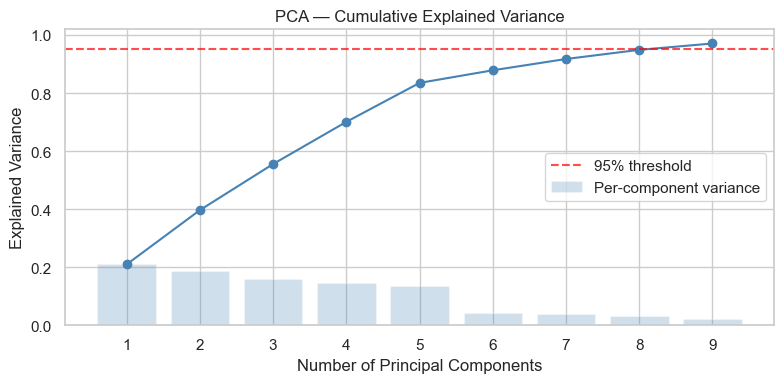

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train.values)

n_comp  = pca.n_components_
cum_var = pca.explained_variance_ratio_.cumsum()
print(f"PCA: {n_comp} components -> {cum_var[-1]*100:.1f}% variance explained")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_comp + 1), cum_var, 'o-', color='steelblue', ms=6)
ax.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
ax.bar(range(1, n_comp + 1), pca.explained_variance_ratio_,
       color='steelblue', alpha=0.25, label='Per-component variance')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
ax.set_xticks(range(1, n_comp + 1))
plt.tight_layout()
plt.savefig('../figures/03-Dimensionality-Reduction/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(pca, '../data/processed/pca.pkl')

feature_sets['pca'] = {
    'X_train'      : X_train_pca,
    'n_features'   : n_comp,
    'feature_names': [f'PC{i+1}' for i in range(n_comp)],
}

### 3 — LASSO Feature Selection

Fit a multinomial logistic regression with L1 penalty on the training set. Features whose coefficient is zero for **all** classes are dropped.

Selected : 12 features — ['FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Gender_Male', 'family_history_with_overweight_yes', 'FAVC_yes', 'SCC_yes']
Dropped  : 1 features — ['SMOKE_yes']


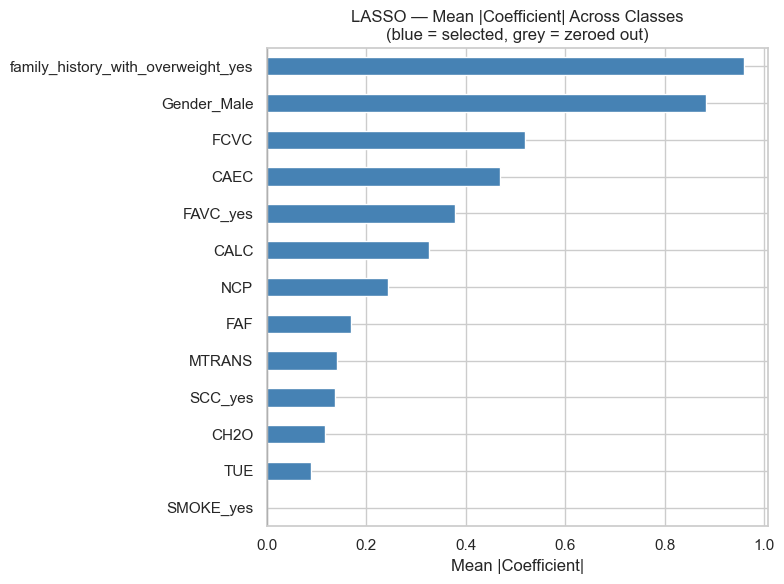

In [5]:
from sklearn.linear_model import LogisticRegression

lasso_selector = LogisticRegression(
    solver='saga', l1_ratio=1, C=0.1,
    max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'
)
lasso_selector.fit(X_train.values, y_train.values)

coef_mask      = (np.abs(lasso_selector.coef_) > 1e-6).any(axis=0)
selected_feats = np.array(list(X_train.columns))[coef_mask]
dropped_feats  = np.array(list(X_train.columns))[~coef_mask]

print(f"Selected : {coef_mask.sum()} features — {selected_feats.tolist()}")
print(f"Dropped  : {(~coef_mask).sum()} features — {dropped_feats.tolist()}")

X_train_lasso = X_train.values[:, coef_mask]

mean_abs_coef = np.abs(lasso_selector.coef_).mean(axis=0)
feat_imp = pd.Series(mean_abs_coef, index=X_train.columns).sort_values()

colors = ['steelblue' if f in selected_feats else 'lightgrey' for f in feat_imp.index]
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('LASSO — Mean |Coefficient| Across Classes\n(blue = selected, grey = zeroed out)')
ax.set_xlabel('Mean |Coefficient|')
plt.tight_layout()
plt.savefig('../figures/03-Dimensionality-Reduction/lasso_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(lasso_selector, '../data/processed/lasso_selector.pkl')
joblib.dump(coef_mask,      '../data/processed/lasso_mask.pkl')

feature_sets['lasso'] = {
    'X_train'      : X_train_lasso,
    'n_features'   : coef_mask.sum(),
    'feature_names': selected_feats.tolist(),
}

## Save Feature Sets

In [6]:
joblib.dump(feature_sets, '../data/processed/feature_sets.pkl')
print("Feature sets saved:")
for name, fs in feature_sets.items():
    print(f"  {name}: {fs['n_features']} features")

Feature sets saved:
  original: 13 features
  pca: 9 features
  lasso: 12 features
